# 05 exotic options

European options have closed-form Black-Scholes solutions; exotic options do not. we then must use Monte Carlo in order to price them. <br>
we implement two common exotics:
- **Asian options**: payoff based on the average price over the path
- **barrier options**: expires worthless if the stock ever crosses a barrier over the path

the simulation is identical to before with changes only being made to the payoff function.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from gbm import simulate_paths
from pricer import bs_pricing

In [2]:
Sof0  = 100
K     = 105
r     = 0.05
sigma = 0.20
T     = 1.0
N     = int(252 * T)
M     = 1000

paths = simulate_paths(Sof0, r, sigma, T, N, M, seed=42)
final = paths[-1, :]
time  = np.linspace(0, T, N + 1)

## on Asian options

a standard European call pays $\max(S_T - K, 0)$, and it only cares about the final price. an Asian call pays $\max(S_{avg} - K, 0)$, where $S_{avg}$ is the arithmetic mean of the stock price over the entire path.

Asian options are therefore:
- cheaper than European options as the average is less volatile than the final price
- harder to manipulate (you can't move the price on a single day to affect the payoff)

In [3]:
# arithmetic average of each path (exclude t=0)
average_prices = paths[1:, :].mean(axis=0)
asian_payoffs  = np.maximum(average_prices - K, 0)
asian_price    = np.exp(-r * T) * asian_payoffs.mean()

# European price for comparison
european_payoffs = np.maximum(final - K, 0)
european_price   = np.exp(-r * T) * european_payoffs.mean()
bs_price         = bs_pricing(Sof0, K, r, sigma, T, option_type='call')

print(f"Asian call price    : ${asian_price:.4f}")
print(f"European call price : ${european_price:.4f}")
print(f"Black-Scholes price : ${bs_price:.4f}")
print(f"Asian discount      : ${european_price - asian_price:.4f}")

Asian call price    : $3.5824
European call price : $8.2280
Black-Scholes price : $8.0214
Asian discount      : $4.6456


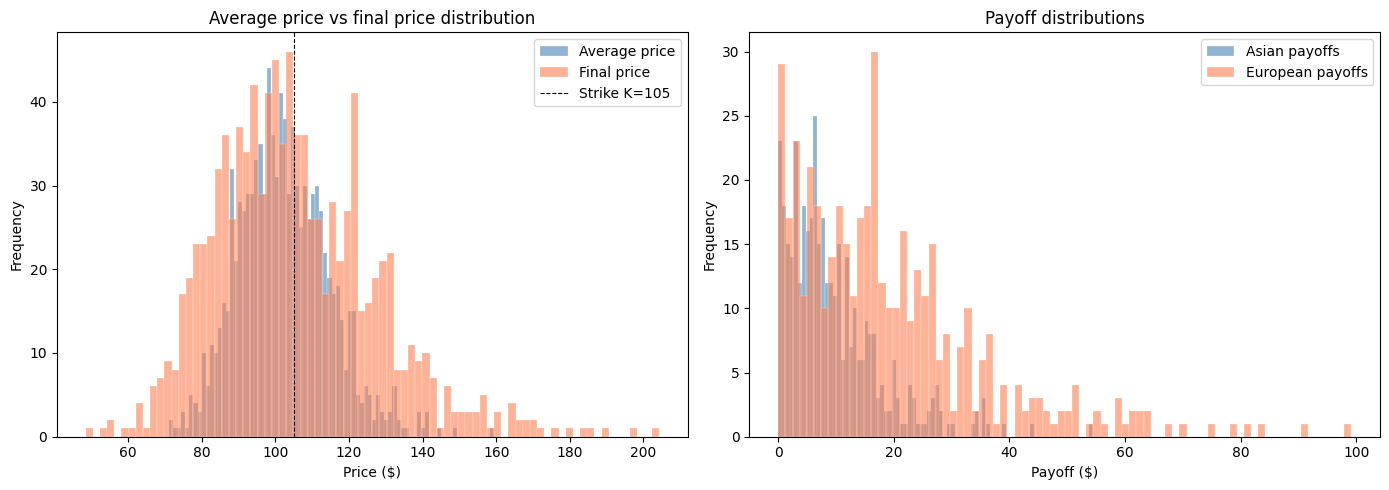

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution of average prices vs final prices
axes[0].hist(average_prices, bins=80, alpha=0.6, color='steelblue',
             label='Average price', edgecolor='white', linewidth=0.3)
axes[0].hist(final, bins=80, alpha=0.6, color='coral',
             label='Final price', edgecolor='white', linewidth=0.3)
axes[0].axvline(K, color='black', linestyle='--', linewidth=0.8, label=f'Strike K={K}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Average price vs final price distribution')
axes[0].legend()

# payoff distributions
axes[1].hist(asian_payoffs[asian_payoffs > 0], bins=80, alpha=0.6,
             color='steelblue', label='Asian payoffs', edgecolor='white', linewidth=0.3)
axes[1].hist(european_payoffs[european_payoffs > 0], bins=80, alpha=0.6,
             color='coral', label='European payoffs', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Payoff ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Payoff distributions')
axes[1].legend()

plt.tight_layout()
plt.show()